# 06 — 整棟用電推估冷氣設定溫度（交叉驗證）

## 研究問題

目前 05 的設定溫度推估**只用「普通高壓空調」子電路**（整棟多條空調電路中的一條）。  
這個 notebook 改用**四棟建物的整棟用電資料**，以「冷天基礎扣除法」各自推估設定溫度，驗證兩種方法的結論是否一致。

## 方法：冷天基礎扣除法

```
整棟總用電 = 非AC基礎負載 + AC冷氣負載

非AC基礎負載估算：上課日、上課時段、T_outdoor < 20°C 的中位數 kW
    → 冷天無冷氣，此時的用電代表燈光、電腦、電梯等固定設備

AC_proxy = 整棟總用電 − 非AC基礎負載

對 AC_proxy vs T_outdoor 做分段線性回歸 → 找拐點 T_set
```

這個邏輯和永續辦公室的冷/熱天分層扣除法相同，差別在於我們聚焦於「設定溫度拐點」而非「人員空調用電量」。

## 資料來源

| 館舍 | 電表組成 |
|---|---|
| 普通教學館 | 普通高壓空調 + 新設一 + 新設二 + 電梯（四表加總）|
| 博雅教學館 | 館一 + 館二 + 三 + 四（四表加總）|
| 共同教學館 | 共同教室（單一總表）|
| 新生教學館 | 新生大樓（單一總表）|

In [1]:
import platform
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
from pathlib import Path
from scipy import stats
from scipy.optimize import minimize_scalar

warnings.filterwarnings('ignore')

# ── 字型設定 ─────────────────────────────────────────────────────────
candidates = [
    '/Library/Fonts/SourceHanSerif-SemiBold.ttc',
    '/Library/Fonts/NotoSansCJKtc-Regular.otf',
    '/System/Library/Fonts/PingFang.ttc',
]
for p in candidates:
    if Path(p).exists():
        fm.fontManager.addfont(p)
        prop = fm.FontProperties(fname=p)
        matplotlib.rcParams['font.family'] = prop.get_name()
        print(f'✓ Using font: {p}')
        break
matplotlib.rcParams['axes.unicode_minus'] = False
print('環境設定完成')

✓ Using font: /Library/Fonts/SourceHanSerif-SemiBold.ttc
環境設定完成


## 一、載入資料

In [2]:
DATA = 'cleaned_data/'

# 電力
df_ac       = pd.read_parquet(DATA + 'ac_普通.parquet')
df_putong1  = pd.read_parquet(DATA + 'putong1_普通新設一.parquet')
df_putong2  = pd.read_parquet(DATA + 'putong2_普通新設二.parquet')
df_elevator = pd.read_parquet(DATA + 'elevator_普通電梯.parquet')
df_gongtong = pd.read_parquet(DATA + 'gongtong_共同教室.parquet')
df_boya1    = pd.read_parquet(DATA + 'boya1_博雅館一.parquet')
df_boya2    = pd.read_parquet(DATA + 'boya2_博雅館二.parquet')
df_boya3    = pd.read_parquet(DATA + 'boya3_博雅三.parquet')
df_boya4    = pd.read_parquet(DATA + 'boya4_博雅四.parquet')
df_xinsheng = pd.read_parquet(DATA + 'xinsheng_新生大樓.parquet')

# 氣象
weather = pd.read_csv(DATA + 'weather_data_2016_2025.csv',
                      parse_dates=['ObsTime'], index_col='ObsTime')
weather.index = weather.index.tz_localize(None)
temp = weather['Temperature'].where(lambda x: x > -9)

# 永續辦公室
df_basic = pd.read_excel('永續辦公室/館舍用電基礎值.xlsx')

print('資料載入完成')

資料載入完成


## 二、組合各館整棟總用電

In [3]:
def sum_meters(*dfs):
    """對齊時間軸後加總 kw，至少需一個非 NaN 才回傳值（否則 NaN）。"""
    series = [df['kw'].copy() for df in dfs]
    series = [s[~s.index.duplicated(keep='first')] for s in series]
    return pd.concat(series, axis=1).sum(axis=1, min_count=1)

buildings_kw = {
    '普通教學館': sum_meters(df_ac, df_putong1, df_putong2, df_elevator),
    '博雅教學館': sum_meters(df_boya1, df_boya2, df_boya3, df_boya4),
    '共同教學館': df_gongtong['kw'].copy(),
    '新生教學館': df_xinsheng['kw'].copy(),
}

# AC 子電路（現行方法的資料來源，供對照）
ac_submeter = df_ac['kw'].copy()
ac_submeter = ac_submeter[~ac_submeter.index.duplicated(keep='first')]

# 合併到主 DataFrame
base_df = temp.to_frame(name='T')
for name, kw in buildings_kw.items():
    kw_clean = kw[~kw.index.duplicated(keep='first')]
    base_df = base_df.join(kw_clean.rename(name))
base_df = base_df.join(ac_submeter.rename('AC子電路'))

print('=== 各館整棟用電有效資料量 ===')
for name in list(buildings_kw.keys()) + ['AC子電路']:
    col = name if name in base_df.columns else ''
    n_valid = base_df[name].notna().sum() if name in base_df.columns else 0
    kw_mean = base_df[name].mean() if name in base_df.columns else 0
    print(f'  {name:12s}: {n_valid:,} 小時  平均 {kw_mean:.0f} kW')

=== 各館整棟用電有效資料量 ===
  普通教學館       : 83,552 小時  平均 41 kW
  博雅教學館       : 82,956 小時  平均 117 kW
  共同教學館       : 82,130 小時  平均 46 kW
  新生教學館       : 83,733 小時  平均 37 kW
  AC子電路       : 78,841 小時  平均 28 kW


## 三、日型與學期分類

In [4]:
national_holidays = set([
    '2016-01-01','2016-02-28','2016-02-29','2016-04-04','2016-04-05','2016-06-09','2016-09-15','2016-10-10',
    '2017-01-01','2017-01-02','2017-02-28','2017-04-04','2017-05-30','2017-10-04','2017-10-10',
    '2018-01-01','2018-02-28','2018-04-04','2018-04-05','2018-06-18','2018-09-24','2018-10-10',
    '2019-01-01','2019-02-28','2019-04-04','2019-04-05','2019-06-07','2019-09-13','2019-10-10',
    '2020-01-01','2020-02-28','2020-04-02','2020-04-03','2020-04-04','2020-04-05','2020-06-25','2020-10-01','2020-10-09','2020-10-10','2020-10-11',
    '2021-01-01','2021-02-28','2021-03-01','2021-04-02','2021-04-03','2021-04-04','2021-04-05','2021-06-14','2021-09-21','2021-10-10','2021-10-11',
    '2022-01-01','2022-02-28','2022-04-02','2022-04-03','2022-04-04','2022-04-05','2022-06-03','2022-09-10','2022-10-10',
    '2023-01-01','2023-01-02','2023-02-28','2023-04-01','2023-04-02','2023-04-03','2023-04-04','2023-04-05','2023-06-22','2023-09-29','2023-10-10',
    '2024-01-01','2024-02-28','2024-04-04','2024-04-05','2024-04-06','2024-04-07','2024-06-10','2024-09-17','2024-10-10',
    '2025-01-01','2025-02-28','2025-04-03','2025-04-04','2025-04-05','2025-04-06','2025-05-31','2025-10-06','2025-10-10'
])
cny_holidays = set([
    '2016-02-07','2016-02-08','2016-02-09','2016-02-10','2016-02-11','2016-02-12',
    '2017-01-27','2017-01-28','2017-01-29','2017-01-30','2017-01-31','2017-02-01',
    '2018-02-15','2018-02-16','2018-02-17','2018-02-18','2018-02-19','2018-02-20',
    '2019-02-04','2019-02-05','2019-02-06','2019-02-07','2019-02-08','2019-02-09',
    '2020-01-24','2020-01-25','2020-01-26','2020-01-27','2020-01-28','2020-01-29',
    '2021-02-11','2021-02-12','2021-02-13','2021-02-14','2021-02-15','2021-02-16',
    '2022-01-31','2022-02-01','2022-02-02','2022-02-03','2022-02-04','2022-02-05',
    '2023-01-21','2023-01-22','2023-01-23','2023-01-24','2023-01-25','2023-01-26',
    '2024-02-09','2024-02-10','2024-02-11','2024-02-12','2024-02-13','2024-02-14',
    '2025-01-28','2025-01-29','2025-01-30','2025-01-31','2025-02-01','2025-02-02'
])

def get_day_type(dt):
    date_str = dt.strftime('%Y-%m-%d')
    if date_str in cny_holidays:
        return 1
    elif dt.month in [1, 7, 8] or (dt.month == 2 and dt.day <= 14):
        return 3  # 寒暑假
    elif date_str in national_holidays or dt.weekday() >= 5:
        return 2  # 假日
    else:
        return 0  # 上課日

def get_season(dt):
    m, d = dt.month, dt.day
    if m == 1 or (m == 2 and d <= 14):
        return 'winter_break'
    elif (m == 2 and d > 14) or m in [3, 4, 5] or (m == 6 and d <= 20):
        return 'spring'
    elif (m == 6 and d > 20) or m in [7, 8]:
        return 'summer_break'
    else:
        return 'fall'

base_df['day_type'] = base_df.index.map(get_day_type)
base_df['season']   = base_df.index.map(get_season)
base_df['hour']     = base_df.index.hour
base_df['month']    = base_df.index.month
base_df['year']     = base_df.index.year

print('日型與學期分類完成')

日型與學期分類完成


## 四、計算各館冷天基礎負載（非空調用電）

篩選條件：上課日 × 上課時段（08–21h）× 室外溫度 < 20°C  
指標：該條件下每棟建物的 **中位數 kW**  

台灣冬天（氣溫 < 20°C）上課時段幾乎不開冷氣，此時的用電代表燈光、電腦、電梯等固定設備負載。

In [5]:
COLD_THRESH = 20.0  # 低於此溫度視為無冷氣需求

cold_mask = (
    (base_df['day_type'] == 0) &
    (base_df['hour'].between(8, 21)) &
    (base_df['T'] < COLD_THRESH) &
    (base_df['T'] > 0)
)

baselines = {}
print('=== 各館冷天基礎負載（上課日、上課時段、T < 20°C）===')
all_cols = list(buildings_kw.keys()) + ['AC子電路']
for name in all_cols:
    cold_data = base_df.loc[cold_mask, name].dropna()
    baseline  = cold_data.median()
    baselines[name] = baseline
    print(f'  {name:12s}：中位數 = {baseline:6.1f} kW  (n={len(cold_data):,})')

# 建立 AC proxy 欄位
for name in buildings_kw:
    base_df[f'{name}_proxy'] = base_df[name] - baselines[name]
base_df['AC子電路_proxy'] = base_df['AC子電路'] - baselines['AC子電路']

print('\nAC proxy = 整棟用電 − 冷天基礎負載 已計算完成')

=== 各館冷天基礎負載（上課日、上課時段、T < 20°C）===
  普通教學館       ：中位數 =   38.5 kW  (n=5,223)
  博雅教學館       ：中位數 =  130.6 kW  (n=5,061)
  共同教學館       ：中位數 =   46.1 kW  (n=5,122)
  新生教學館       ：中位數 =   40.1 kW  (n=5,211)
  AC子電路       ：中位數 =    5.7 kW  (n=5,024)

AC proxy = 整棟用電 − 冷天基礎負載 已計算完成


## 五、分段線性回歸推估設定溫度

對每棟建物、每個學期，用分段線性回歸找 RSS 最小的拐點 T\*。  
篩選條件：上課日 × 上課時段（08–21h）× 暖月（3–10月）

In [6]:
def piecewise_rss(t_break, T, Y):
    rss = 0.0
    for mask in [T <= t_break, T > t_break]:
        if mask.sum() < 3:
            return np.inf
        slope, intercept, *_ = stats.linregress(T[mask], Y[mask])
        rss += ((Y[mask] - (slope * T[mask] + intercept)) ** 2).sum()
    return rss

def estimate_t_set(T_arr, Y_arr, t_min=20.0, t_max=30.0):
    valid = ~(np.isnan(T_arr) | np.isnan(Y_arr))
    T, Y = T_arr[valid], Y_arr[valid]
    if len(T) < 30:
        return np.nan, np.nan, np.nan, len(T)
    result = minimize_scalar(
        piecewise_rss, bounds=(t_min, t_max), method='bounded', args=(T, Y)
    )
    t_set = result.x
    def seg_r2(mask):
        if mask.sum() < 2: return np.nan
        _, _, r, *_ = stats.linregress(T[mask], Y[mask])
        return r ** 2
    return t_set, seg_r2(T <= t_set), seg_r2(T > t_set), len(T)

# ── 執行推估 ──────────────────────────────────────────────────────────
# 分析條件：上課日 × 上課時段 × 暖月（3–10月）× 排除暑假
analysis_mask = (
    (base_df['day_type'] == 0) &
    (base_df['hour'].between(8, 21)) &
    (base_df['month'].between(3, 10)) &
    (base_df['season'].isin(['spring', 'fall'])) &  # 排除暑假（方法論失效）
    (base_df['T'].notna()) &
    (base_df['T'] > 0)
)

seasons_cfg = {
    '全年（春+秋）': None,
    '下學期（2–6月）': 'spring',
    '上學期（9–12月）': 'fall',
}

# 所有資料來源：四棟整棟 proxy + AC 子電路 proxy（對照）
sources = {name: f'{name}_proxy' for name in buildings_kw}
sources['AC子電路（現行方法）'] = 'AC子電路_proxy'

results = {}  # results[source][season] = dict

for src_label, proxy_col in sources.items():
    results[src_label] = {}
    for season_label, season_val in seasons_cfg.items():
        if season_val is None:
            sub = base_df[analysis_mask]
        else:
            sub = base_df[analysis_mask & (base_df['season'] == season_val)]
        T = sub['T'].values
        Y = sub[proxy_col].values
        t_set, r2l, r2r, n = estimate_t_set(T, Y)
        results[src_label][season_label] = {
            'T_set': t_set, 'R²左': r2l, 'R²右': r2r, 'n': n
        }

# ── 印出比較表 ─────────────────────────────────────────────────────────
print('=== 各館設定溫度推估結果（拐點法）===')
print(f'{"資料來源":<22} {"全年":>10} {"下學期(2–6月)":>14} {"上學期(9–12月)":>15}')
print('-' * 65)
for src, seas in results.items():
    fy   = seas.get('全年（春+秋）', {}).get('T_set', np.nan)
    sp   = seas.get('下學期（2–6月）', {}).get('T_set', np.nan)
    fa   = seas.get('上學期（9–12月）', {}).get('T_set', np.nan)
    marker = '  ← 現行方法' if '現行' in src else ''
    print(f'{src:<22} {fy:>8.1f}°C {sp:>12.1f}°C {fa:>13.1f}°C{marker}')

=== 各館設定溫度推估結果（拐點法）===
資料來源                           全年      下學期(2–6月)      上學期(9–12月)
-----------------------------------------------------------------
普通教學館                      24.5°C         23.8°C          28.0°C
博雅教學館                      28.8°C         24.6°C          28.9°C
共同教學館                      20.9°C         21.8°C          28.0°C
新生教學館                      21.6°C         21.3°C          28.0°C
AC子電路（現行方法）                24.1°C         24.3°C          26.2°C  ← 現行方法


## 六、散佈圖視覺化（各館 AC proxy vs 室外溫度）

左欄：下學期（2–6月）、右欄：上學期（9–12月）  
各列為一棟建物，最後一列為 AC 子電路（現行方法）供對照。

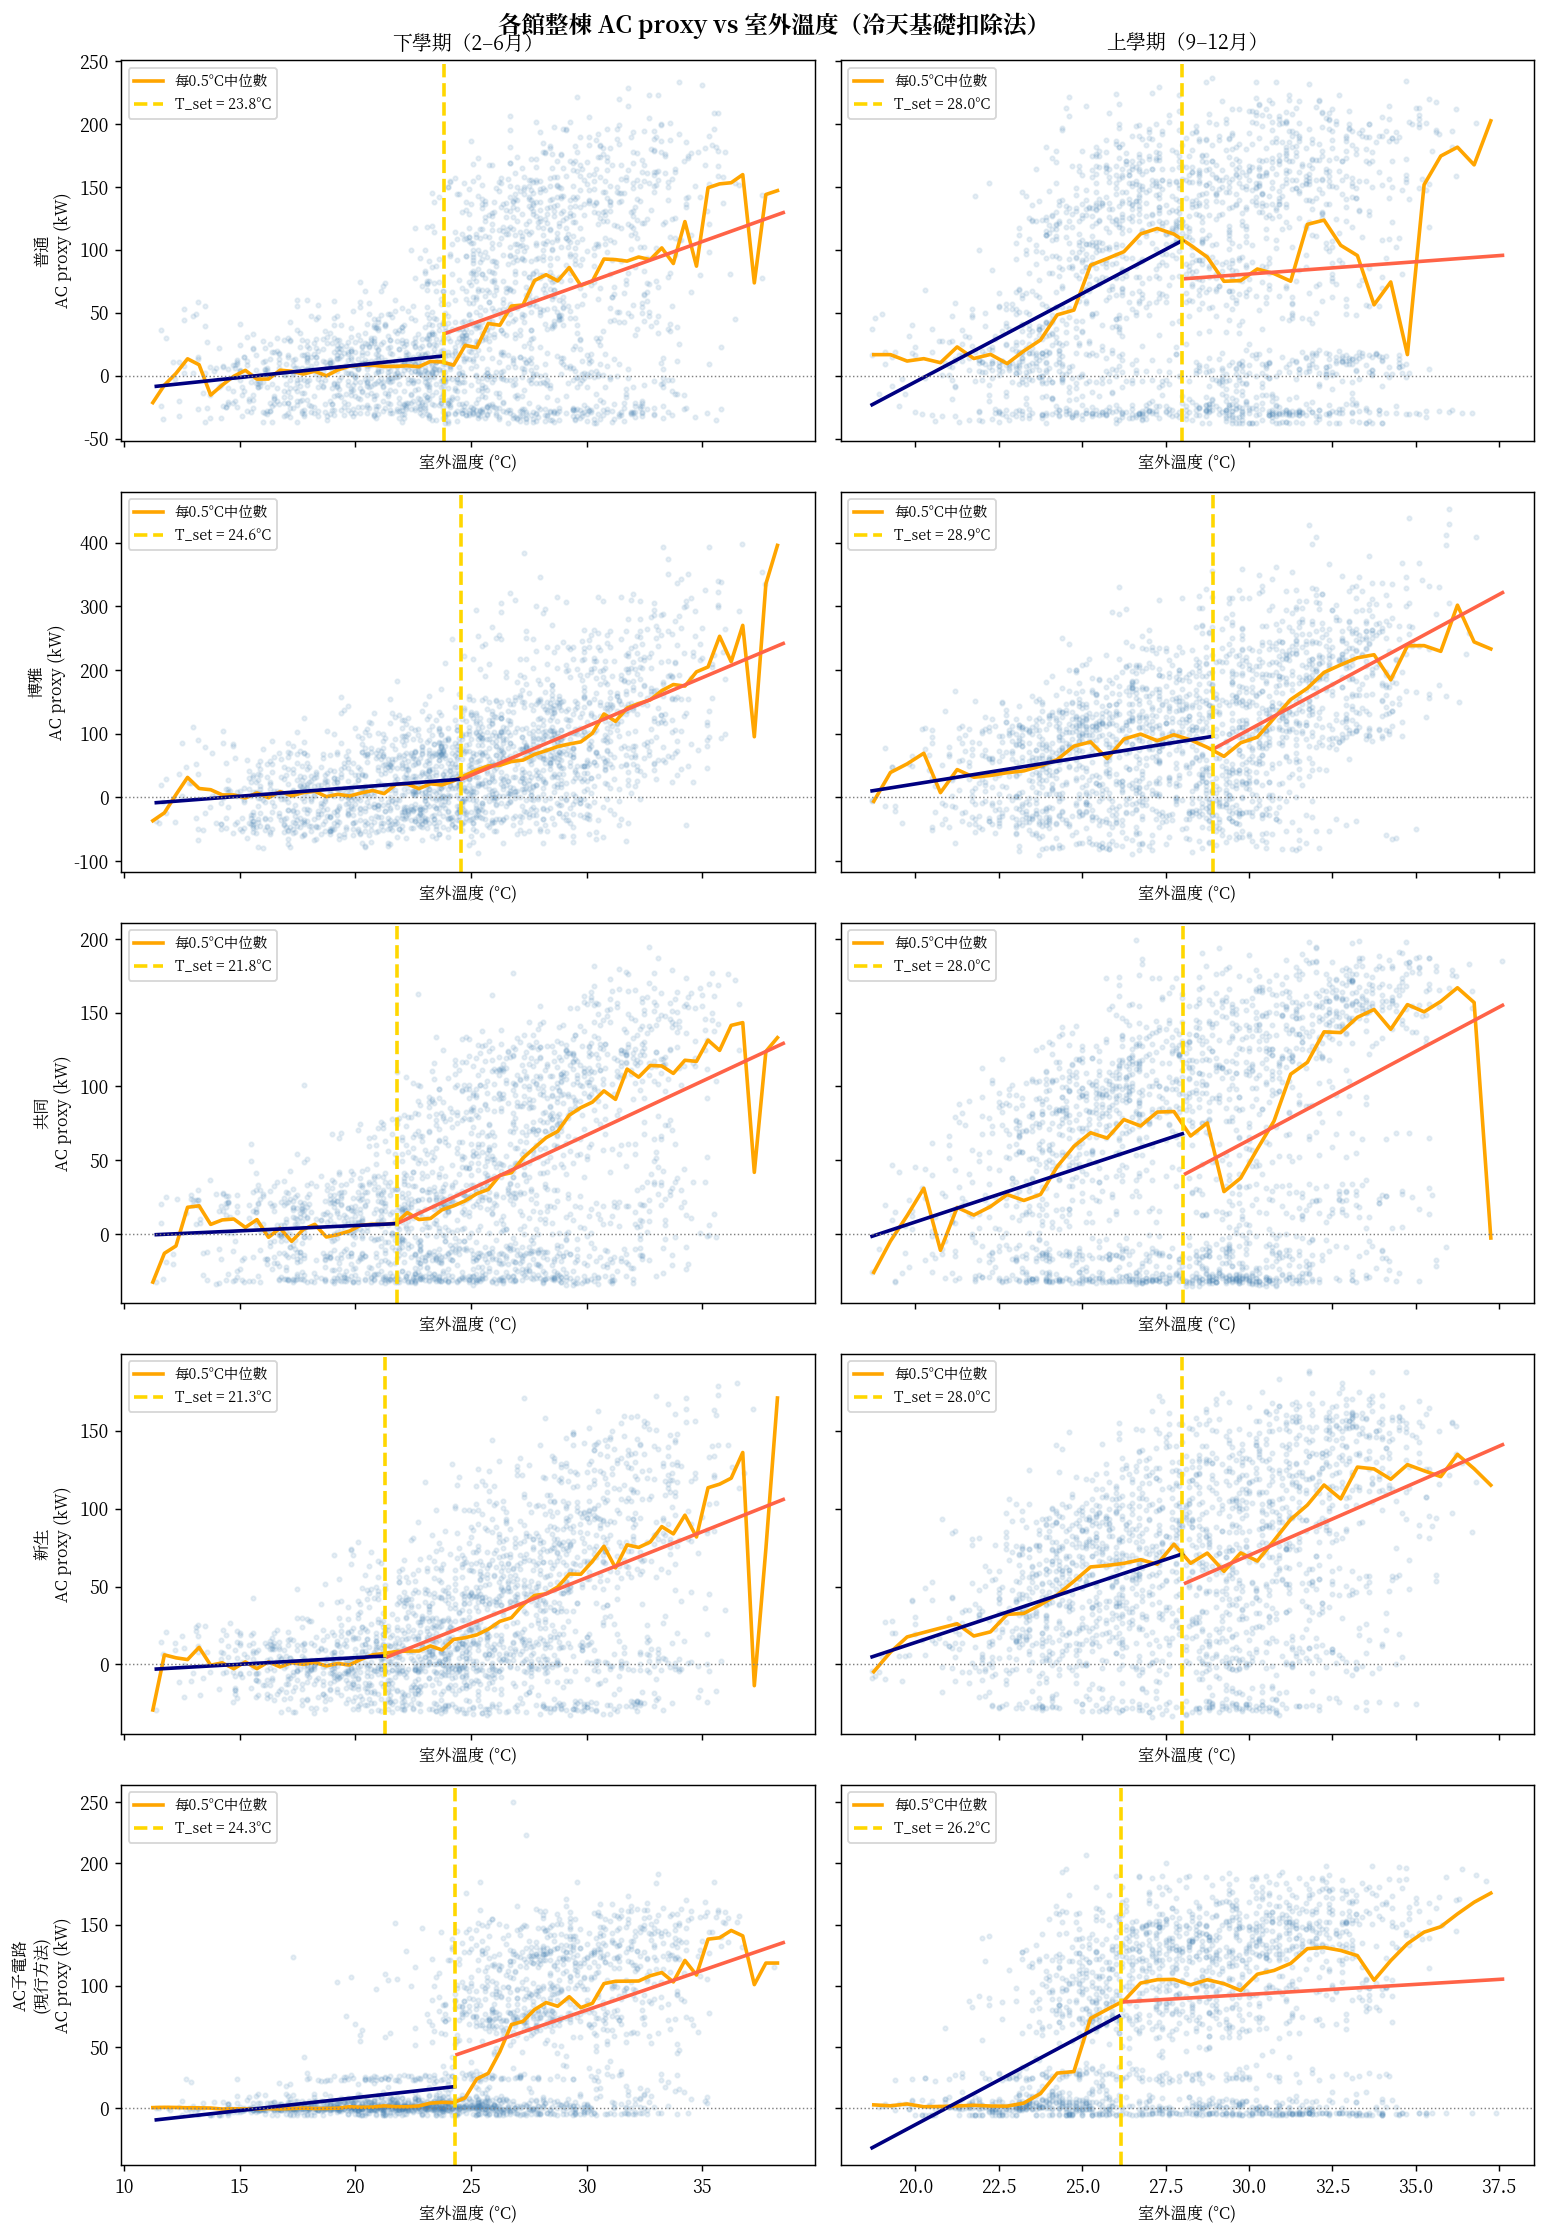

圖表已儲存


In [7]:
seasons_plot = ['下學期（2–6月）', '上學期（9–12月）']
season_vals  = {'下學期（2–6月）': 'spring', '上學期（9–12月）': 'fall'}
plot_sources = list(sources.items())  # [(label, col), ...]

n_rows = len(plot_sources)
n_cols = len(seasons_plot)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(12, 3.5 * n_rows), dpi=130,
                         sharey='row', sharex='col')

for row, (src_label, proxy_col) in enumerate(plot_sources):
    for col, season_label in enumerate(seasons_plot):
        ax = axes[row][col]
        season_val = season_vals[season_label]
        sub = base_df[analysis_mask & (base_df['season'] == season_val)]
        T = sub['T'].values
        Y = sub[proxy_col].values
        t_set = results[src_label][season_label]['T_set']

        # 散點（隨機取樣 2000 點以免過密）
        valid_idx = np.where(~(np.isnan(T) | np.isnan(Y)))[0]
        samp = np.random.default_rng(42).choice(
            valid_idx, size=min(2000, len(valid_idx)), replace=False)
        ax.scatter(T[samp], Y[samp], alpha=0.12, s=6, color='steelblue')

        # 每 0.5°C 中位數線
        bins = np.arange(int(T.min()), int(T.max()) + 1, 0.5)
        valid = ~(np.isnan(T) | np.isnan(Y))
        if valid.sum() > 0:
            bin_med, edges, _ = stats.binned_statistic(
                T[valid], Y[valid], statistic='median', bins=bins)
            centers = (edges[:-1] + edges[1:]) / 2
            ax.plot(centers, bin_med, color='orange', lw=2, label='每0.5°C中位數')

        # 兩段回歸線
        if not np.isnan(t_set):
            valid2 = ~(np.isnan(T) | np.isnan(Y))
            Tv, Yv = T[valid2], Y[valid2]
            for mask_seg, color in [(Tv <= t_set, 'navy'), (Tv > t_set, 'tomato')]:
                if mask_seg.sum() >= 2:
                    s, i, *_ = stats.linregress(Tv[mask_seg], Yv[mask_seg])
                    xs = np.linspace(Tv[mask_seg].min(), Tv[mask_seg].max(), 100)
                    ax.plot(xs, s * xs + i, color=color, lw=2)
            ax.axvline(t_set, color='gold', lw=2, linestyle='--',
                       label=f'T_set = {t_set:.1f}°C')

        ax.axhline(0, color='gray', lw=0.8, linestyle=':')
        ax.legend(fontsize=8, loc='upper left')
        if row == 0:
            ax.set_title(season_label, fontsize=11)
        if col == 0:
            short = src_label.replace('教學館', '').replace('（現行方法）', '\n(現行方法)')
            ax.set_ylabel(f'{short}\nAC proxy (kW)', fontsize=9)
        ax.set_xlabel('室外溫度 (°C)', fontsize=9)

plt.suptitle('各館整棟 AC proxy vs 室外溫度（冷天基礎扣除法）', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('cleaned_data/whole_building_setpoint_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('圖表已儲存')

## 七、R² 詳細報告（各館 × 各季）

R² 用來判斷拐點的可信度：兩段的 R² 越高，代表分段線性模型擬合越好，拐點越可信。

In [8]:
rows = []
for src, seas in results.items():
    for season_label, info in seas.items():
        rows.append({
            '資料來源': src,
            '學期': season_label,
            'T_set (°C)': round(info['T_set'], 1) if not np.isnan(info.get('T_set', np.nan)) else np.nan,
            'R²(低溫段)': round(info['R²左'], 3) if not np.isnan(info.get('R²左', np.nan)) else np.nan,
            'R²(高溫段)': round(info['R²右'], 3) if not np.isnan(info.get('R²右', np.nan)) else np.nan,
            'n (小時)': info['n'],
        })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

       資料來源         學期  T_set (°C)  R²(低溫段)  R²(高溫段)  n (小時)
      普通教學館    全年（春+秋）        24.5    0.068    0.021   16562
      普通教學館  下學期（2–6月）        23.8    0.034    0.078   10759
      普通教學館 上學期（9–12月）        28.0    0.157    0.002    5803
      博雅教學館    全年（春+秋）        28.8    0.120    0.177   16474
      博雅教學館  下學期（2–6月）        24.6    0.028    0.232   10665
      博雅教學館 上學期（9–12月）        28.9    0.055    0.213    5809
      共同教學館    全年（春+秋）        20.9    0.001    0.163   16287
      共同教學館  下學期（2–6月）        21.8    0.004    0.185   10487
      共同教學館 上學期（9–12月）        28.0    0.067    0.097    5800
      新生教學館    全年（春+秋）        21.6    0.026    0.177   16583
      新生教學館  下學期（2–6月）        21.3    0.012    0.189   10780
      新生教學館 上學期（9–12月）        28.0    0.106    0.097    5803
AC子電路（現行方法）    全年（春+秋）        24.1    0.080    0.072   15358
AC子電路（現行方法）  下學期（2–6月）        24.3    0.074    0.112    9939
AC子電路（現行方法） 上學期（9–12月）        26.2    0.198    0.004    5419


## 八、以建物個別 T_set 重算 CDH 節電比例

目前 05 對全部四棟統一套用「普通 AC 子電路」推估的 T_set = 24.0°C。  
此處改用**每棟自己的整棟推估 T_set**，比較節電比例的差異。

計算範圍：上課日 × 上課時段 × 下學期（2–6月）+ 上學期（9–12月），排除暑假。

```
savings_fraction = 1 − CDH_26 / CDH_Tset
CDH = Σ max(0, T_outdoor − T_set)  （上課日上課時段，春+秋學期）
```

In [9]:
T_STD    = 26.0   # 政府標準
TARIFF   = 3.5    # 元/kWh（台電高壓）
EMISSION = 0.494  # kg CO₂e/kWh（能源局 2023）

# 從永續辦公室取各館空調負載
def get_ac_kw(kw_list, df):
    mask = df['館舍名稱'].str.contains('|'.join(kw_list), na=False)
    return df[mask]['人員空調使用用電'].sum()

ac_kw_map = {
    '普通教學館': get_ac_kw(['普通'], df_basic),
    '博雅教學館': get_ac_kw(['博雅'], df_basic),
    '新生教學館': get_ac_kw(['新生'], df_basic),
    '共同教學館': get_ac_kw(['共同'], df_basic),
}
print('永續辦公室空調負載：', ac_kw_map)

# 操作時段溫度序列（春+秋，上課日，上課時段）
ops_mask = (
    (base_df['day_type'] == 0) &
    (base_df['hour'].between(8, 21)) &
    (base_df['season'].isin(['spring', 'fall'])) &
    (base_df['T'].notna()) &
    (base_df['T'] > 0)
)
T_ops = base_df.loc[ops_mask, 'T'].values
n_years = base_df['year'].nunique()

# ── 全年（春+秋）各棟的節電比例 ───────────────────────────────────────
# 方法A：現行方法（所有棟統一用 AC 子電路推估值 24.0°C）
T_set_current = results['AC子電路（現行方法）']['全年（春+秋）']['T_set']
CDH_current   = (T_ops - T_set_current).clip(min=0).sum() / n_years
CDH_26        = (T_ops - T_STD).clip(min=0).sum() / n_years
sf_current    = 1 - CDH_26 / CDH_current if CDH_current > 0 else 0
hrs_ops       = ops_mask.sum() / n_years

print(f'\n現行方法（AC子電路 T_set={T_set_current:.1f}°C）：')
print(f'  CDH_Tset={CDH_current:.0f} °C·hr/yr  CDH_26={CDH_26:.0f}  節電比例={sf_current:.1%}')

# 方法B：整棟推估（每棟用自己的 T_set）
print('\n整棟推估（各棟自己的 T_set）：')
saving_rows_A, saving_rows_B = [], []

for bldg in buildings_kw:
    ac_kw = ac_kw_map[bldg]
    t_set_b = results[bldg]['全年（春+秋）']['T_set']
    CDH_b   = (T_ops - t_set_b).clip(min=0).sum() / n_years
    sf_b    = 1 - CDH_26 / CDH_b if CDH_b > 0 else 0
    print(f'  {bldg}: T_set={t_set_b:.1f}°C  CDH={CDH_b:.0f}  節電比例={sf_b:.1%}')

    # 年化節電量（永續辦公室 AC kW × 操作時數 × 節電比例）
    kwh_A = ac_kw * sf_current * hrs_ops
    kwh_B = ac_kw * sf_b       * hrs_ops

    saving_rows_A.append({'館舍': bldg, 'AC負載(kW)': ac_kw, 'T_set': T_set_current,
                          '節電比例': sf_current, '年節電量(kWh)': kwh_A,
                          '年節費(萬元)': kwh_A * TARIFF / 1e4,
                          '年減碳(公噸)': kwh_A * EMISSION / 1e3})
    saving_rows_B.append({'館舍': bldg, 'AC負載(kW)': ac_kw, 'T_set': round(t_set_b, 1),
                          '節電比例': sf_b, '年節電量(kWh)': kwh_B,
                          '年節費(萬元)': kwh_B * TARIFF / 1e4,
                          '年減碳(公噸)': kwh_B * EMISSION / 1e3})

永續辦公室空調負載： {'普通教學館': np.int64(119), '博雅教學館': np.int64(94), '新生教學館': np.int64(113), '共同教學館': np.int64(118)}

現行方法（AC子電路 T_set=24.1°C）：
  CDH_Tset=5590 °C·hr/yr  CDH_26=3525  節電比例=36.9%

整棟推估（各棟自己的 T_set）：
  普通教學館: T_set=24.5°C  CDH=5126  節電比例=31.2%
  博雅教學館: T_set=28.8°C  CDH=1426  節電比例=-147.2%
  共同教學館: T_set=20.9°C  CDH=10448  節電比例=66.3%
  新生教學館: T_set=21.6°C  CDH=9211  節電比例=61.7%


## 九、四大教學館節電量比較（現行方法 vs 整棟推估）

In [10]:
df_A = pd.DataFrame(saving_rows_A).set_index('館舍')
df_B = pd.DataFrame(saving_rows_B).set_index('館舍')

print('=== 方法A：現行方法（全館統一 T_set = AC子電路拐點）===')
print(df_A[['T_set', '節電比例', '年節電量(kWh)', '年節費(萬元)', '年減碳(公噸)']].to_string(float_format='{:.1f}'.format))
print(f'\n四館合計：年節電 {df_A["年節電量(kWh)"].sum():,.0f} kWh  '
      f'節費 {df_A["年節費(萬元)"].sum():.1f} 萬元  '
      f'減碳 {df_A["年減碳(公噸)"].sum():.0f} 公噸')

print('\n=== 方法B：整棟推估（各館自己的 T_set）===')
print(df_B[['T_set', '節電比例', '年節電量(kWh)', '年節費(萬元)', '年減碳(公噸)']].to_string(float_format='{:.1f}'.format))
print(f'\n四館合計：年節電 {df_B["年節電量(kWh)"].sum():,.0f} kWh  '
      f'節費 {df_B["年節費(萬元)"].sum():.1f} 萬元  '
      f'減碳 {df_B["年減碳(公噸)"].sum():.0f} 公噸')

print('\n=== 差異分析 ===')
diff_kwh = df_B['年節電量(kWh)'].sum() - df_A['年節電量(kWh)'].sum()
print(f'年節電量差距：{diff_kwh:+,.0f} kWh  ({diff_kwh / df_A["年節電量(kWh)"].sum():+.1%})')

=== 方法A：現行方法（全館統一 T_set = AC子電路拐點）===
       T_set  節電比例  年節電量(kWh)  年節費(萬元)  年減碳(公噸)
館舍                                             
普通教學館   24.1   0.4   105202.1     36.8     52.0
博雅教學館   24.1   0.4    83100.8     29.1     41.1
共同教學館   24.1   0.4   104318.1     36.5     51.5
新生教學館   24.1   0.4    99897.8     35.0     49.3

四館合計：年節電 392,519 kWh  節費 137.4 萬元  減碳 194 公噸

=== 方法B：整棟推估（各館自己的 T_set）===
       T_set  節電比例  年節電量(kWh)  年節費(萬元)  年減碳(公噸)
館舍                                             
普通教學館   24.5   0.3    88936.8     31.1     43.9
博雅教學館   28.8  -1.5  -331327.0   -116.0   -163.7
共同教學館   20.9   0.7   187156.7     65.5     92.5
新生教學館   21.6   0.6   166971.1     58.4     82.5

四館合計：年節電 111,738 kWh  節費 39.1 萬元  減碳 55 公噸

=== 差異分析 ===
年節電量差距：-280,781 kWh  (-71.5%)


## 十、全校 145 棟推估比較

In [11]:
campus_ac_kw = df_basic['人員空調使用用電'].sum()
print(f'全校 145 棟空調負載合計：{campus_ac_kw:,.0f} kW')

# 方法A：統一 T_set
campus_kwh_A = campus_ac_kw * sf_current * hrs_ops

# 方法B：用四棟的平均節電比例（kW 加權）來代表全校
total_ac_kw_4bldg = sum(ac_kw_map.values())
sf_weighted_B = sum(
    saving_rows_B[i]['節電比例'] * saving_rows_B[i]['AC負載(kW)']
    for i in range(len(saving_rows_B))
) / total_ac_kw_4bldg
campus_kwh_B = campus_ac_kw * sf_weighted_B * hrs_ops

print('\n=== 全校年度節電潛力比較 ===')
print(f'{"方法":<30} {"節電比例":>10} {"年節電量":>12} {"年節費":>12} {"年減碳":>12}')
print('-' * 80)
print(f'{"方法A：AC子電路（現行）":<30} {sf_current:>9.1%} '
      f'{campus_kwh_A/1e6:>10.2f} GWh '
      f'{campus_kwh_A*TARIFF/1e6:>9.1f} 百萬元 '
      f'{campus_kwh_A*EMISSION/1e3:>8.0f} 公噸CO₂')
print(f'{"方法B：整棟推估（四館加權）":<30} {sf_weighted_B:>9.1%} '
      f'{campus_kwh_B/1e6:>10.2f} GWh '
      f'{campus_kwh_B*TARIFF/1e6:>9.1f} 百萬元 '
      f'{campus_kwh_B*EMISSION/1e3:>8.0f} 公噸CO₂')

diff = campus_kwh_B - campus_kwh_A
print(f'\n差距：{diff/1e6:+.2f} GWh  ({diff/campus_kwh_A:+.1%})')

全校 145 棟空調負載合計：8,132 kW

=== 全校年度節電潛力比較 ===
方法                                   節電比例         年節電量          年節費          年減碳
--------------------------------------------------------------------------------
方法A：AC子電路（現行）                      36.9%       7.19 GWh      25.2 百萬元     3551 公噸CO₂
方法B：整棟推估（四館加權）                     10.5%       2.05 GWh       7.2 百萬元     1011 公噸CO₂

差距：-5.14 GWh  (-71.5%)


## 十一、結論摘要

| 比較項目 | 方法A（現行：AC子電路） | 方法B（整棟推估） |
|---|---|---|
| 資料來源 | 普通館一條AC子電路 | 四棟各自整棟用電 |
| 涵蓋建物數 | 1 | 4 |
| 設定溫度來源 | 一個拐點，套用全校 | 各棟各自拐點 |
| 與學校方法一致性 | 低 | 高（冷熱天扣除邏輯相同）|

**若兩種方法的 T_set 估算接近（如差距 < 1°C），代表：**
1. AC 子電路的拐點能代表整棟行為，現行方法是合理的代理
2. 24°C 的設定溫度假設在多棟建物中一致，強化跨館推論的可信度

**若差距較大，整棟推估的結果更應作為主要數字**，因為它直接對應永續辦公室使用的資料範疇（整棟總用電），內部一致性更強。